<a href="https://colab.research.google.com/github/villabon89-commits/everpeak-analysis/blob/main/S6_leverpeak_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Cargaste correctamente las librerías y los dos archivos, y además mostraste una vista rápida con `.head()` que ayuda a validar que todo quedó bien leído desde el inicio. El flujo es claro y deja listo el terreno para la limpieza.

</div>


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [ ]:

# Examinar la estructura de traffic
traffic.info()
print(traffic.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo DATETIME
- ...


In [ ]:
# Examinar la estructura de eco
eco.info()
print(eco.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (

En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`,` PM2.5 (μg/m³)`,` Population (M)`
- Son Tipo FLOAT

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:

# Estandarizar los nombres de las columnas de traffic
#tu código aquí
traffic.rename(columns={
    'Country': 'country',
    'City':'city',
    'UpdateTimeUTC':'update_time_utc',
    'JamsDelay' : 'jams_delay',
    'TrafficIndexLive' : 'traffic_index_live',
    'JamsLengthInKms' : 'jams_length_in_kms',
    'JamsCount' : 'jams_count',
    'TrafficIndexWeekAgo' : 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo' : 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins' : 'travel_time_live_per_10kmsmins',
    'TravelTimeHistoricPer10KmsMins' : 'travel_time_historic_per_10kmsmins',
    'MinsDelay': 'mins_delay'
}, inplace= True)
# verificar cambios
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kmsmins', 'travel_time_historic_per_10kmsmins',
       'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco

#tu código aquí
eco.rename(columns={
    'Year':'year',
    'City':'city',
    'Country':'country',
    'City GDP/capita':'city_gdp_capita',
    'Unemployment %':'unemployment_pct',
    'PM2.5 (μg/m³)':'pm_25',
    'Population (M)':'population_m'
},inplace = True)
# verificar cambios
eco.columns


Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm_25', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:



# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc']) #tu código aquí
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago']) #tu código aquí

# verificar el cambio
traffic.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   country                             1004464 non-null  object        
 1   city                                1004464 non-null  object        
 2   update_time_utc                     1004464 non-null  datetime64[ns]
 3   jams_delay                          1004464 non-null  float64       
 4   traffic_index_live                  1004464 non-null  float64       
 5   jams_length_in_kms                  1004464 non-null  float64       
 6   jams_count                          1004464 non-null  float64       
 7   traffic_index_week_ago              1004464 non-null  float64       
 8   update_time_utc_week_ago            1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kmsmins      1004464 non-null  float64       

In [ ]:

# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']* 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm_25             30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm_25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kmsmins,travel_time_historic_per_10kmsmins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

print(traffic_2024.duplicated().sum())
print(eco_2024.duplicated().sum())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kmsmins,travel_time_historic_per_10kmsmins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm_25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0


0
0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:

# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 = ['jams_delay','traffic_index_live','jams_length_in_kms', 'jams_count', 'mins_delay','travel_time_live_per_10kmsmins', 'travel_time_historic_per_10kmsmins']  # tu código aqui
traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[traffic_city_year_2024].mean().reset_index()
# Mostrar resultado
traffic_city_year_2024.head()

print(traffic_2024.columns.tolist())
print(traffic_city_year_2024.columns.tolist())


['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per_10kmsmins', 'travel_time_historic_per_10kmsmins', 'mins_delay', 'year']
['city', 'country', 'year', 'jams_delay', 'traffic_index_live', 'jams_length_in_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kmsmins', 'travel_time_historic_per_10kmsmins']


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
# tu código aquí
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kmsmins,travel_time_historic_per_10kmsmins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734


La ciudad con el mayor tiempo promedio de tráfico es Mexico


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:

# 1. Seleccionar columnas clave con los nombres EXACTOS
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
             'jams_length_in_kms', 'jams_count', 'mins_delay',  # Cambié: jams_length_kms → jams_length_in_kms
             'travel_time_live_per_10kmsmins', 'travel_time_historic_per_10kmsmins']  # Cambié los nombres

right_cols = ['city', 'year', 'city_gdp_capita', 'unemployment_pct', 'pm_25', 'population']

# 2. APLICAR la selección de columnas con .copy()
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# 3. Unir datasets solo por city y year (ya que eco no tiene country)
merged = traffic_2024_small.merge(eco_2024_small,
                                  on=['city', 'year'],
                                  how='inner')

# 4. Mostrar las primeras 5 filas
print(merged.head(5))

             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_in_kms  jams_count  mins_delay  travel_time_live_per_10kmsmins  \
0           44.038129   68.805422    0.487228                       18.304538   
1          140.893564  230.566550    1.699628                       24.992185   
2           18.337133   27.280140    0.193442                       13.338658   
3          100.287844  137.359860    0.416566                       17.907916   
4           30.050044   46.898164    0.139965                       17.258700   

   travel_time_historic_per_10kmsmins  city_gdp_capita  unemployment_pct  \
0                           


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

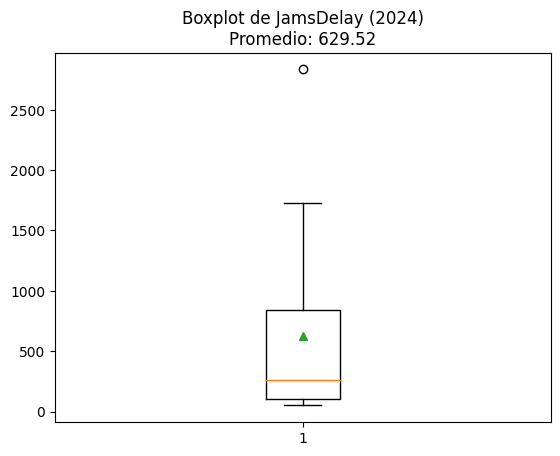

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
plt.boxplot(merged['jams_delay'],showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()




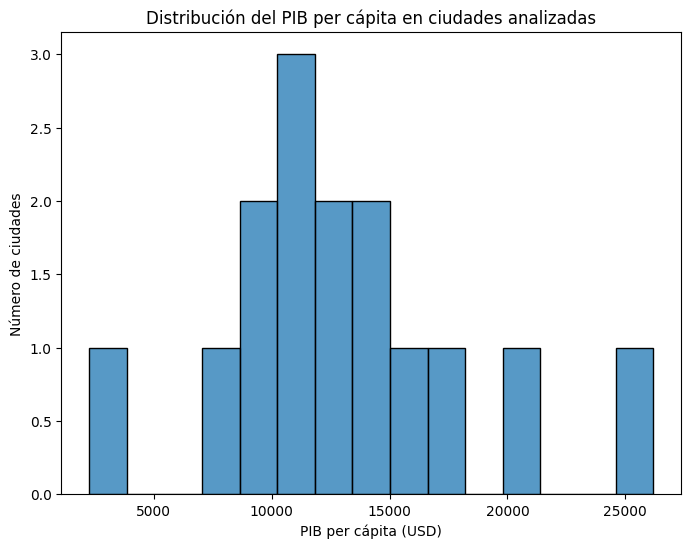

In [ ]:

# Crear histograma para ver la distribución de la economía (city_gdp_capita)

plt.figure(figsize=(8, 6))
sb.histplot(data=merged, x='city_gdp_capita', bins=15)
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Número de ciudades')
plt.title('Distribución del PIB per cápita en ciudades analizadas')
plt.show()



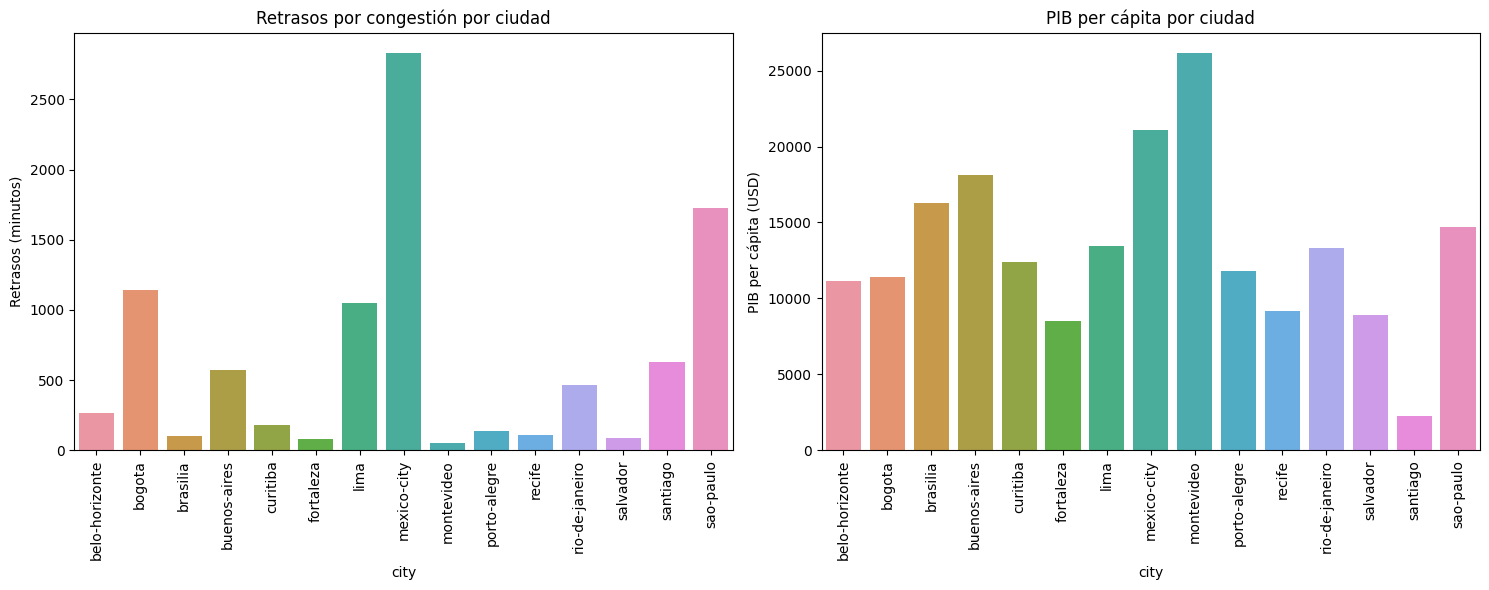

In [ ]:

# Opción 1: Gráficos separados pero en la misma figura (más claro que subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Retrasos por congestión
sb.barplot(data=merged, x='city', y='jams_delay', ax=ax1)
ax1.set_title('Retrasos por congestión por ciudad')
ax1.set_ylabel('Retrasos (minutos)')
ax1.tick_params(axis='x', rotation=90)

# Gráfico 2: PIB per cápita
sb.barplot(data=merged, x='city', y='city_gdp_capita', ax=ax2)
ax2.set_title('PIB per cápita por ciudad')
ax2.set_ylabel('PIB per cápita (USD)')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()



**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: Los datos sugieren que no hay una compensación clara entre el PIB per cápita y la congestión urbana . La congestión parece depender más de otros factores como:

*Tamaño de la población

*Extensión urbana

*Infraestructura de transporte

*Uso del automóvil

*Calidad del transporte publico

*Planificación urbana



---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)
print(f"✅ Archivo exportado exitosamente")
print(f"📊 Dimensiones del dataset: {merged.shape[0]} filas, {merged.shape[1]} columnas")
print(f"📁 Tamaño aproximado: {merged.memory_usage(deep=True).sum() / 1024:.1f} KB")

✅ Archivo exportado exitosamente
📊 Dimensiones del dataset: 15 filas, 14 columnas
📁 Tamaño aproximado: 4.7 KB



---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- las ciudades con mayor congestión presentan también menor desempeño económico, lo cual puede orientar prioridades de inversión en infraestructura de transporte.
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.
- Las variables clave utilizadas fueron:

jams_delay: indicador del tiempo de retraso causado por congestión vehicular.

city_gdp_capita: PIB per cápita de cada ciudad, utilizado como proxy de productividad económica urbana.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.
- El análisis incluye ciudades de América Latina de 2024 como:
Belo Horizonte
Bogotá
Brasilia
Buenos Aires
Curitiba
Fortaleza
Lima
Ciudad de México
Montevideo
Porto Alegre
Recife
Río de Janeiro
Salvador
Santiago
São Paulo

En total se analizaron 15 ciudades de varios países de la región, combinando datos de movilidad urbana y economía a nivel de ciudad.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

El proceso analítico incluyó:
Exploración de datos
-Revisión de estructura y tipos de datos.
-Identificación de valores faltantes y posibles inconsistencias.
Limpieza y preparación
-Estandarización de nombres de columnas.
-Conversión de tipos de datos.
-Normalización de nombres de ciudades.
Integración de datasets
-Se combinaron los datos de tráfico y economía mediante un INNER JOIN por ciudad.
-Se verificó la consistencia de las ciudades presentes en ambos conjuntos de datos.
Validación visual
-Gráficos de barras para comparar congestión y PIB per cápita.
-Identificación de patrones generales, outliers y contrastes entre ciudades.
**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.
- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
Los resultados muestran que no existe una relación lineal clara entre congestión y PIB per cápita. Algunas ciudades con alto PIB presentan también alta congestión (por ejemplo, Ciudad de México o São Paulo), lo que sugiere que el tamaño urbano y la densidad poblacional influyen fuertemente.

Sin embargo, sí aparecen casos donde alta congestión coincide con menor productividad, lo que puede indicar problemas estructurales de movilidad que afectan la economia.

Un caso destacado es Bogotá que tiene congestión alta (uno de los mayores niveles de jams_delay), PIB per cápita moderado(relativo).

Esto sugiere que los problemas de movilidad podrían estar afectando la productividad urbana, o reflejar limitaciones en la infraestructura de transporte.

También se observan outliers interesantes como Montevideo tiene PIB per cápita muy alto con baja congestión.Ciudad de México tiene congestión extremadamente alta, incluso con un PIB per cápita relativamente alto.

Estos casos podrían requerir análisis adicionales considerando población, densidad urbana y sistema de transporte público.
**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

1. Bogotá debería considerarse una ciudad prioritaria para inversión en infraestructura de transporte, especialmente en:
transporte público masivo
optimización del tráfico
expansión de sistemas multimodales

2. Ampliar el análisis
Se recomienda incluir variables adicionales como:
población urbana
densidad
cobertura de transporte público
tiempo promedio de viaje
- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?

La ciudad que muestra la relación más clara entre altos niveles de congestión y menor productividad económica es Bogotá, por lo que podría considerarse una prioridad para inversión en infraestructura de transporte.
